# Exploratory Data Analysis (EDA)

This notebook explores the cleaned DVF dataset.

Objectives:
- Perform 1D analysis
- Perform 2D analysis
- Understand property transaction patterns
- Identify relationships between variables

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")

print("Libraries loaded successfully")

Libraries loaded successfully


In [7]:
DATA_PATH = "../data/processed/dvf_clean_sample.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (100000, 23)


/var/folders/sc/1v323g_j3vn3_p105yxkhd2c0000gn/T/ipykernel_84825/306915792.py:3: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,Type de voie,Code voie,Voie,Code postal,Commune,...,No plan,1er lot,Nombre de lots,Code type local,Type local,Surface reelle bati,Nombre pieces principales,Nature culture,Surface terrain,source_file
0,1,2021-01-05,Vente,185000.0,5080.0,CHE,0471,DE VOGELAS,1370.0,VAL-REVERMONT,...,122,NaN,0,3.0,Dépendance,0.0,0.0,S,2410.0,valeursfoncieres-2021.txt.zip
1,1,2021-01-05,Vente,185000.0,5080.0,CHE,0471,DE VOGELAS,1370.0,VAL-REVERMONT,...,122,NaN,0,1.0,Maison,97.0,5.0,S,2410.0,valeursfoncieres-2021.txt.zip
2,1,2021-01-06,Vente,10.0,NaN,NaN,B043,ROUGEMONT,1290.0,BEY,...,204,NaN,0,NaN,NaN,NaN,NaN,BT,530.0,valeursfoncieres-2021.txt.zip
3,1,2021-01-04,Vente,204332.0,7.0,ALL,0276,DES ECUREUILS,1310.0,BUELLAS,...,1325,NaN,0,1.0,Maison,88.0,4.0,S,866.0,valeursfoncieres-2021.txt.zip
4,1,2021-01-06,Vente,320000.0,87.0,RTE,0140,DE CERTINES,1250.0,MONTAGNAT,...,11,NaN,0,3.0,Dépendance,0.0,0.0,S,1426.0,valeursfoncieres-2021.txt.zip


## 1D Analysis

In [8]:
df["Type local"].value_counts()

Type local
Maison                                      20624
Dépendance                                  17173
Appartement                                  8949
Local industriel. commercial ou assimilé     3026
Name: count, dtype: int64

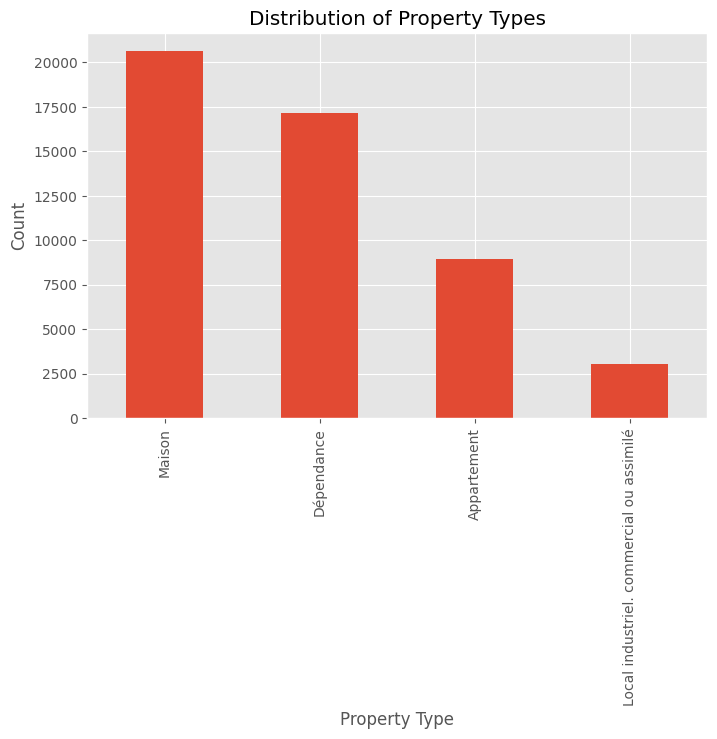

In [9]:
df["Type local"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Property Types")
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.show()

In [10]:
df["Nature mutation"].value_counts()

Nature mutation
Vente                                 95542
Vente en l'état futur d'achèvement     2535
Echange                                1248
Adjudication                            459
Vente terrain à bâtir                   216
Name: count, dtype: int64

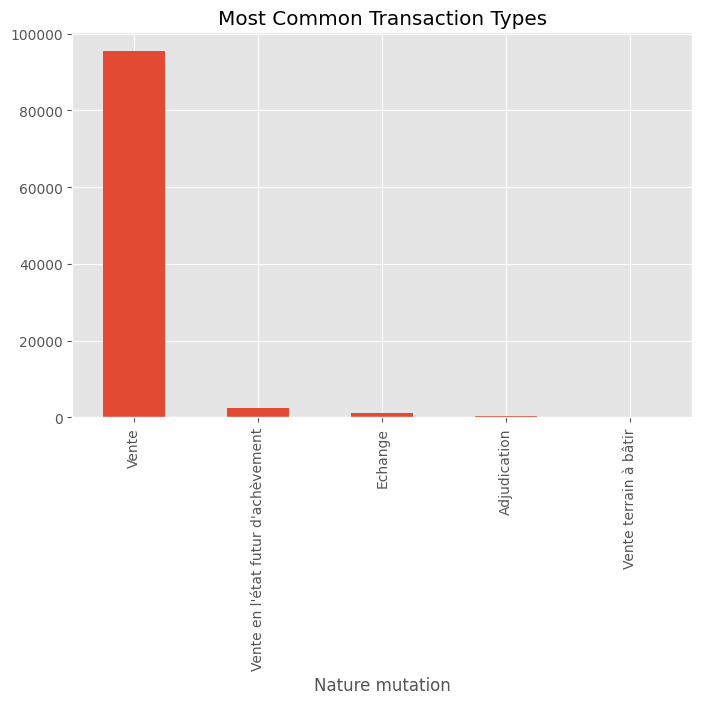

In [11]:
df["Nature mutation"].value_counts().head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Most Common Transaction Types")
plt.show()

In [12]:
df["Valeur fonciere"].describe()

count    1.000000e+05
mean     2.191289e+05
std      5.552538e+05
min      6.000000e-01
25%      4.700000e+04
50%      1.250000e+05
75%      2.390000e+05
max      2.496468e+07
Name: Valeur fonciere, dtype: float64

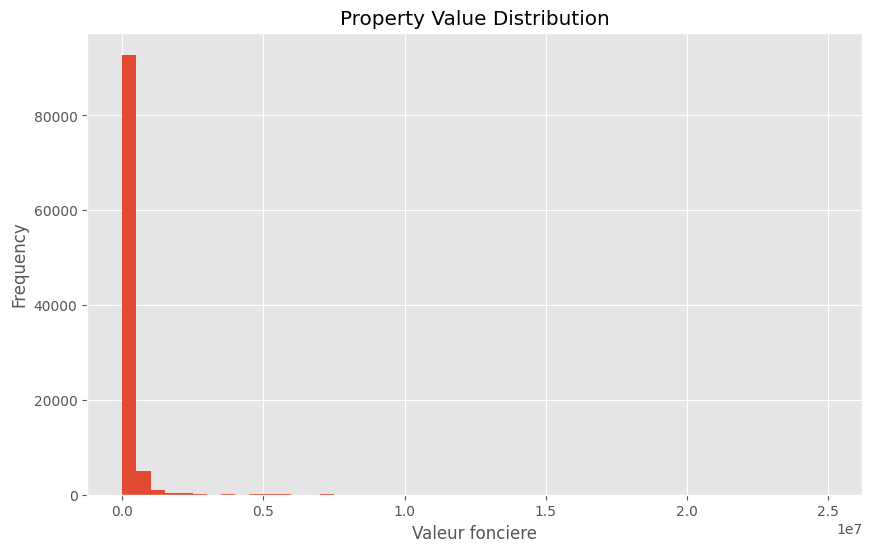

In [13]:
plt.figure(figsize=(10,6))

df["Valeur fonciere"].hist(
    bins=50
)

plt.title("Property Value Distribution")
plt.xlabel("Valeur fonciere")
plt.ylabel("Frequency")
plt.show()

## 2D Analysis

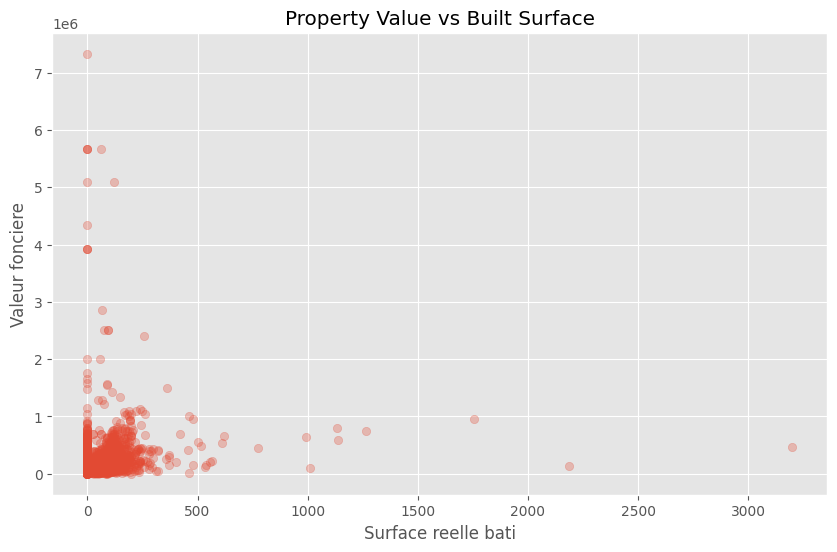

In [14]:
sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df["Surface reelle bati"],
    sample_df["Valeur fonciere"],
    alpha=0.3
)

plt.title("Property Value vs Built Surface")
plt.xlabel("Surface reelle bati")
plt.ylabel("Valeur fonciere")
plt.show()

In [15]:
avg_price = (
    df.groupby("Type local")
      ["Valeur fonciere"]
      .mean()
      .sort_values(ascending=False)
)

avg_price

Type local
Local industriel. commercial ou assimilé    387053.504732
Appartement                                 294374.167037
Dépendance                                  247647.287787
Maison                                      210010.722755
Name: Valeur fonciere, dtype: float64

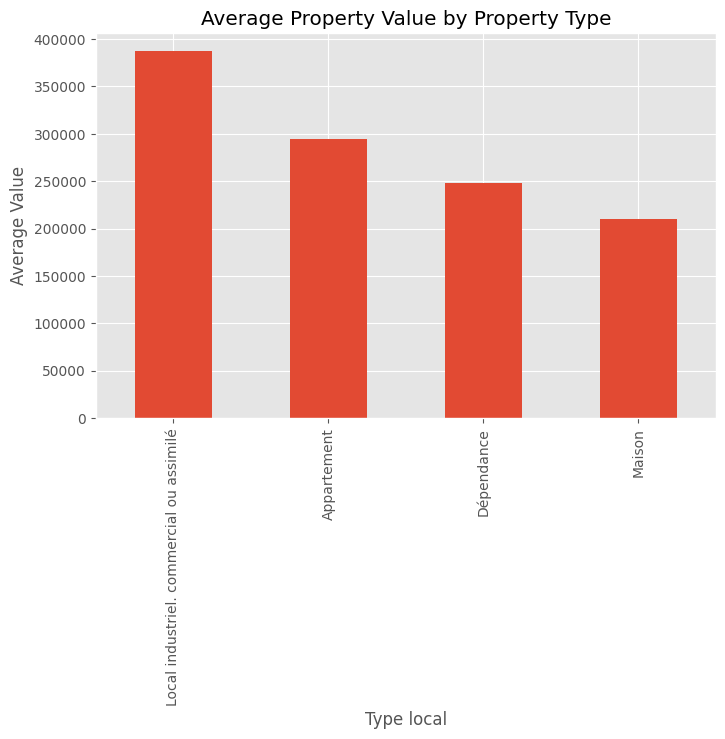

In [16]:
avg_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Property Value by Property Type")
plt.ylabel("Average Value")
plt.show()

## Observations

- Houses and apartments represent the majority of transactions.
- Property values vary significantly across property types.
- Larger built surfaces generally correspond to higher property values.
- Some extreme values indicate potential outliers in the dataset.